In [1]:
import numpy as np
import matplotlib.pyplot as plt

import preprocessing as prep
import visualization as vis
from filtering import LPF

In [2]:
DATA_DIR = "prometheus-hf-1"

SENSORS = {"b_load_1": "LC1 Axial Load",
           "pres_1": "PT1 Combustion Chamber Pressure",
           "pres_2": "PT2 Ox Feedline Pressure",
           "pres_3": "PT3 Ix Injector Pressure",
           "pres_4": "PT4 Ox-Tank Pressure",
           "pres_5": "PT5 BPS ",
           "pres_6": "Flowmeter"}

DRIVERS = {0: {"name": "Ox Fill", "False": "Close", "True": "Open"},
            1: {"name": "Ox Ground Vent", "False": "Close", "True": "Open"},
            5: {"name": "BPS", "False": "Open", "True": "Close"},
            3: {"name": "Fuel Ground Vent", "False": "Close", "True": "Open"},
            4: {"name": "Fuel Remote Purge", "False": "Close", "True": "Open"},
            7: {"name": "Ox Remote Purge", "False": "Close", "True": "Open"},
            8: {"name": "Fuel Fill", "False": "Close", "True": "Open"},
            6: {"name": "Ignition", "False": "Shutoff", "True": "Ignite"}}

In [3]:
print("Processing events")
prep.process_events_quonkboard(DATA_DIR, DRIVERS)
print("Processing data")
prep.process_data(DATA_DIR, SENSORS)
print("Done!")
# 33
# 6509

Processing events
 contents: 55562
55562
Processing data
Done!


In [4]:
events = prep.import_events(DATA_DIR)
#print(events[57])
#events = [{'secs': '9695', 'elapsed': '00:00', 'delta': '00:00', 'type': 'Ignition', 'info': ''}, {'secs': '10000', 'elapsed': '00:00', 'delta': '00:00', 'type': 'End', 'info': ''}]
labels, data = prep.import_data(DATA_DIR, events)
#print(labels)
times = data[:,0]  
   
print(f"HF6 Data Summary \n----------------- \n Sensors: {len(labels) - 1} \n" f" Samples: {len(times)} \n Events:  {len(events)}")

HF6 Data Summary 
----------------- 
 Sensors: 7 
 Samples: 2481901 
 Events:  63


In [5]:
ep = vis.EventPlotter(data, events, dpi=100)
lpf = LPF(fs=300, length=101, cutoff=50, window="blackman")


1380300
1392300
cc_pt
[-38.14926 -38.14926 -38.05346 ... -38.14926 -37.95766 -38.62826]


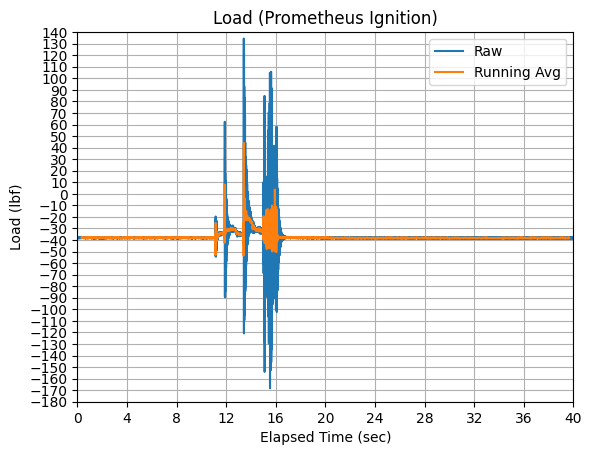

In [11]:
ep.plot(sensor_id=1, event_id=43, duration=40, filter=lpf,
        title="Load (Prometheus Ignition)", ylabel="Load (lbf)",
        num_xticks=11, dif_yticks=10)


1380300
1392300
cc_pt
[-38.14926 -38.14926 -38.05346 ... -38.14926 -37.95766 -38.62826]


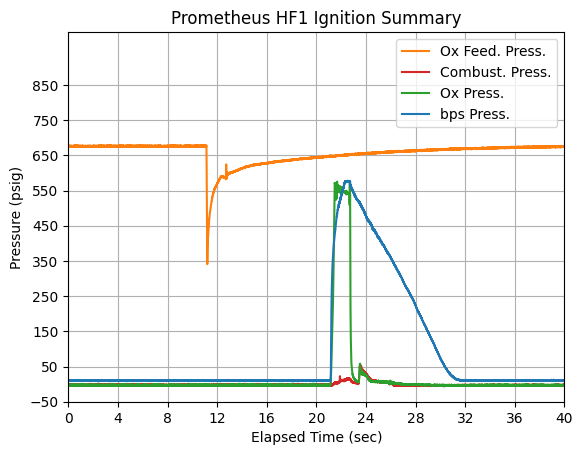

In [14]:
ep.plot(sensor_id=3, event_id=43, duration=40, filter=None,
        title="Prometheus HF1 Ignition Summary", ylabel="Pressure (psig)",
        legend="Ox Feed. Press.", num_xticks=11, dif_yticks=100,color="tab:orange")
ep.add_curve(sensor_id=2, event_id=43, duration=40, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=4, event_id=43, duration=40, legend="Ox Press.",
             color="tab:green")
ep.add_curve(sensor_id=5, event_id=43, duration=40, legend="bps Press.",
             color="tab:blue")

plt.ylim(0,1000)
plt.yticks(range(-50, 901, 100)) 

plt.grid(True)
plt.show()


1382400
1442400
[276.45888 276.45888 276.45888 ... 276.45888 276.45888 276.45888]


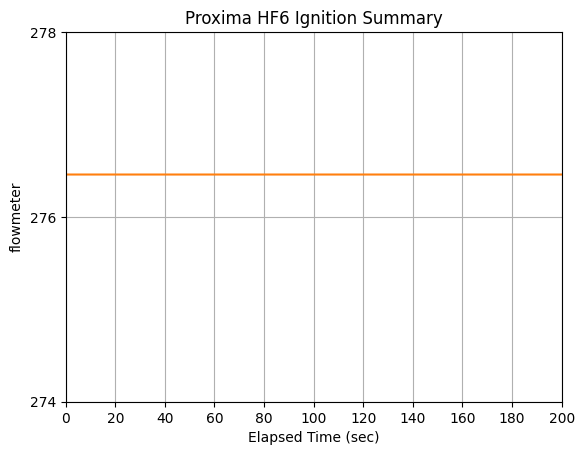

In [29]:
ep.plot(sensor_id=6, event_id=45, duration=200, filter=None,
        title="Proxima HF6 Ignition Summary", ylabel="flowmeter",
        legend="flowrate", num_xticks=11, dif_yticks=2,color="tab:orange")


1382400
1394400
[-37.86185 -38.34086 -38.05346 ... -38.24506 -38.14926 -38.24506]


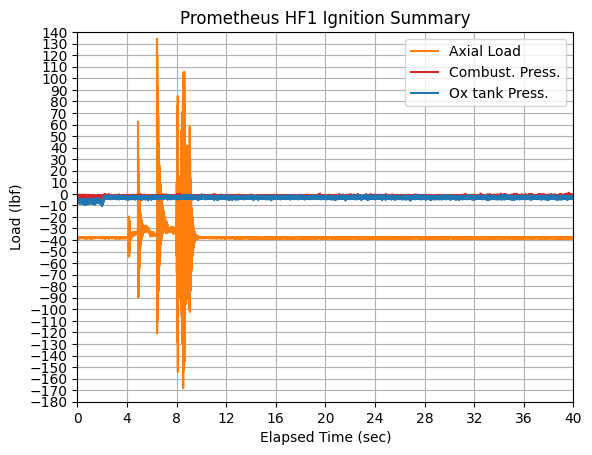

In [30]:
ep.plot(sensor_id=1, event_id=45, duration=40, filter=None,
        title="Prometheus HF1 Ignition Summary", ylabel="Load (lbf)",
        legend="Axial Load", num_xticks=11, dif_yticks=10, color="tab:orange",)
ep.add_curve(sensor_id=2, event_id=45, duration=40, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=4, event_id=23, duration=40, legend="Ox tank Press.", 
             color="tab:blue")
plt.show()